In [1]:
##############################
####  Importing XES files  ###
##############################
import os
import pm4py
from pm4py.objects.log.importer.xes import importer as xes_importer
from pm4py.util import constants
import pandas as pd
from pm4py.objects.log.util import dataframe_utils
from pm4py.objects.conversion.log import converter as log_converter

In [2]:
log = xes_importer.apply('Sepsis Cases - Event Log_1_all/Sepsis Cases - Event Log.xes')

/home/vscode/.local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
parsing log, completed traces :: 100%|██████████| 1050/1050 [00:00<00:00, 3434.23it/s]


### Descriptive statistics of the log

In [3]:
print('Number of cases:', len(log))
print('Number of events:', len([i for case in log._list for i in case._list]))
print('Number of resource (attribute) columns: ', len(pm4py.get_event_attributes(log)))
print('Number of activity labels:', len(pm4py.get_event_attribute_values(log, "concept:name")))

print("Start Time: ", min(pm4py.get_event_attribute_values(log, "time:timestamp")))
print("End Time: ",max(pm4py.get_event_attribute_values(log, "time:timestamp")))

Number of cases: 1050
Number of events: 15214
Number of resource (attribute) columns:  30
Number of activity labels: 16
Start Time:  2013-11-07 08:18:29+00:00
End Time:  2015-06-05 12:25:11+00:00


### Attributes of event log

In [4]:
pm4py.get_event_attributes(log)

['InfectionSuspected',
 'DiagnosticXthorax',
 'Diagnose',
 'Leucocytes',
 'org:group',
 'DiagnosticUrinaryCulture',
 'DiagnosticOther',
 'Infusion',
 'time:timestamp',
 'LacticAcid',
 'DiagnosticECG',
 'SIRSCritHeartRate',
 'DiagnosticLacticAcid',
 'DiagnosticLiquor',
 'DiagnosticArtAstrup',
 'Hypotensie',
 'SIRSCriteria2OrMore',
 'SIRSCritTachypnea',
 'concept:name',
 'SIRSCritTemperature',
 'DiagnosticSputum',
 'DiagnosticBlood',
 'Hypoxie',
 'DiagnosticUrinarySediment',
 'SIRSCritLeucos',
 'DisfuncOrg',
 'DiagnosticIC',
 'Oligurie',
 'Age',
 'CRP']

### List of activities and value of an attribute

In [5]:
activities = pm4py.get_event_attribute_values(log, "concept:name")
resources = pm4py.get_event_attribute_values(log, "Infusion")
print("List of activities:", activities)
print("Value of the attribute (Infusion): ", resources)

List of activities: {'ER Registration': 1050, 'Leucocytes': 3383, 'CRP': 3262, 'LacticAcid': 1466, 'ER Triage': 1053, 'ER Sepsis Triage': 1049, 'IV Liquid': 753, 'IV Antibiotics': 823, 'Admission NC': 1182, 'Release A': 671, 'Return ER': 294, 'Admission IC': 117, 'Release B': 56, 'Release C': 25, 'Release D': 24, 'Release E': 6}
Value of the attribute (Infusion):  {True: 796, False: 254}


### Number of cases with specific activity: 'Return ER'

In [6]:
tracefilter_log_pos = pm4py.filter_event_attribute_values(log, "concept:name", ["Return ER"], level="case", retain=True)
len(tracefilter_log_pos._list)

294

### Detect Process Variants 

In [7]:
variants = pm4py.get_variants(log)
variant_freqs = {variant: len(traces) for variant, traces in variants.items()}
sorted_var_freqs = sorted(variant_freqs.items(), key=lambda x: x[1], reverse=True)

print("Most Popular Variants")
for variant, count in sorted_var_freqs[:10]:
    print(f"Count: {count} | Variant {' -> '.join(variant)}")
    
popular_variants = [v for v in variant_freqs.items() if v[1]>1]
print(f"# of variants with frequency > 1: {len(popular_variants)}")
unpopular_variants = [v for v in variant_freqs.items() if v[1]==1]
print(f"# of variants with frequency = 1: {len(unpopular_variants)}")

Most Popular Variants
Count: 35 | Variant ER Registration -> ER Triage -> ER Sepsis Triage
Count: 24 | Variant ER Registration -> ER Triage -> ER Sepsis Triage -> Leucocytes -> CRP
Count: 22 | Variant ER Registration -> ER Triage -> ER Sepsis Triage -> CRP -> Leucocytes
Count: 13 | Variant ER Registration -> ER Triage -> ER Sepsis Triage -> CRP -> LacticAcid -> Leucocytes -> IV Liquid -> IV Antibiotics
Count: 11 | Variant ER Registration -> ER Triage -> ER Sepsis Triage -> Leucocytes -> CRP -> LacticAcid
Count: 9 | Variant ER Registration -> ER Triage -> ER Sepsis Triage -> Leucocytes -> CRP -> LacticAcid -> IV Liquid -> IV Antibiotics
Count: 7 | Variant ER Registration -> ER Triage -> ER Sepsis Triage -> Leucocytes -> LacticAcid -> CRP -> IV Liquid -> IV Antibiotics
Count: 5 | Variant ER Registration -> ER Triage -> ER Sepsis Triage -> Leucocytes -> CRP -> Admission NC -> Release A
Count: 5 | Variant ER Registration -> ER Triage -> ER Sepsis Triage -> LacticAcid -> Leucocytes -> CRP -

##### Filter out Unpopular variants

This filter out the unpopular variants because otherwise if you feed all 1000+ variants into the Inductive Miner, the resulting model becomes a "spaghetti" that tries to explain everything and is practically useless.

For conformance checking or enhancement we can use the unfiltered log 
Filtered log -> discover a representative process model (baseline)
Full log -> replay against that model -> rare variants surface as non-conforming cases -> analyze why they deviate

In [8]:
cleaned_log = pm4py.filter_variants_top_k(log, k=int(0.4*len(log)))

### Infer Incomplete cases 
"All cases that lack a release activity due to data extraction cuttoff (case is still in progress in extraxtion time ) or poor data quality (wrong enterered timestamps)"

In [11]:
import pandas as pd

log_df = pm4py.convert_to_dataframe(log)

release_activities = {'Release A', 'Release B', 'Release C', 'Release D', 'Release E'}
last_activities = log_df.groupby('case:concept:name')['concept:name'].last()

incomplete_cases = last_activities[~last_activities.isin(release_activities)]
print(f"Incomplete cases: {len(incomplete_cases)} out of {len(last_activities)}")

Incomplete cases: 564 out of 1050


### Draw Directly Follows Graph (DFG)

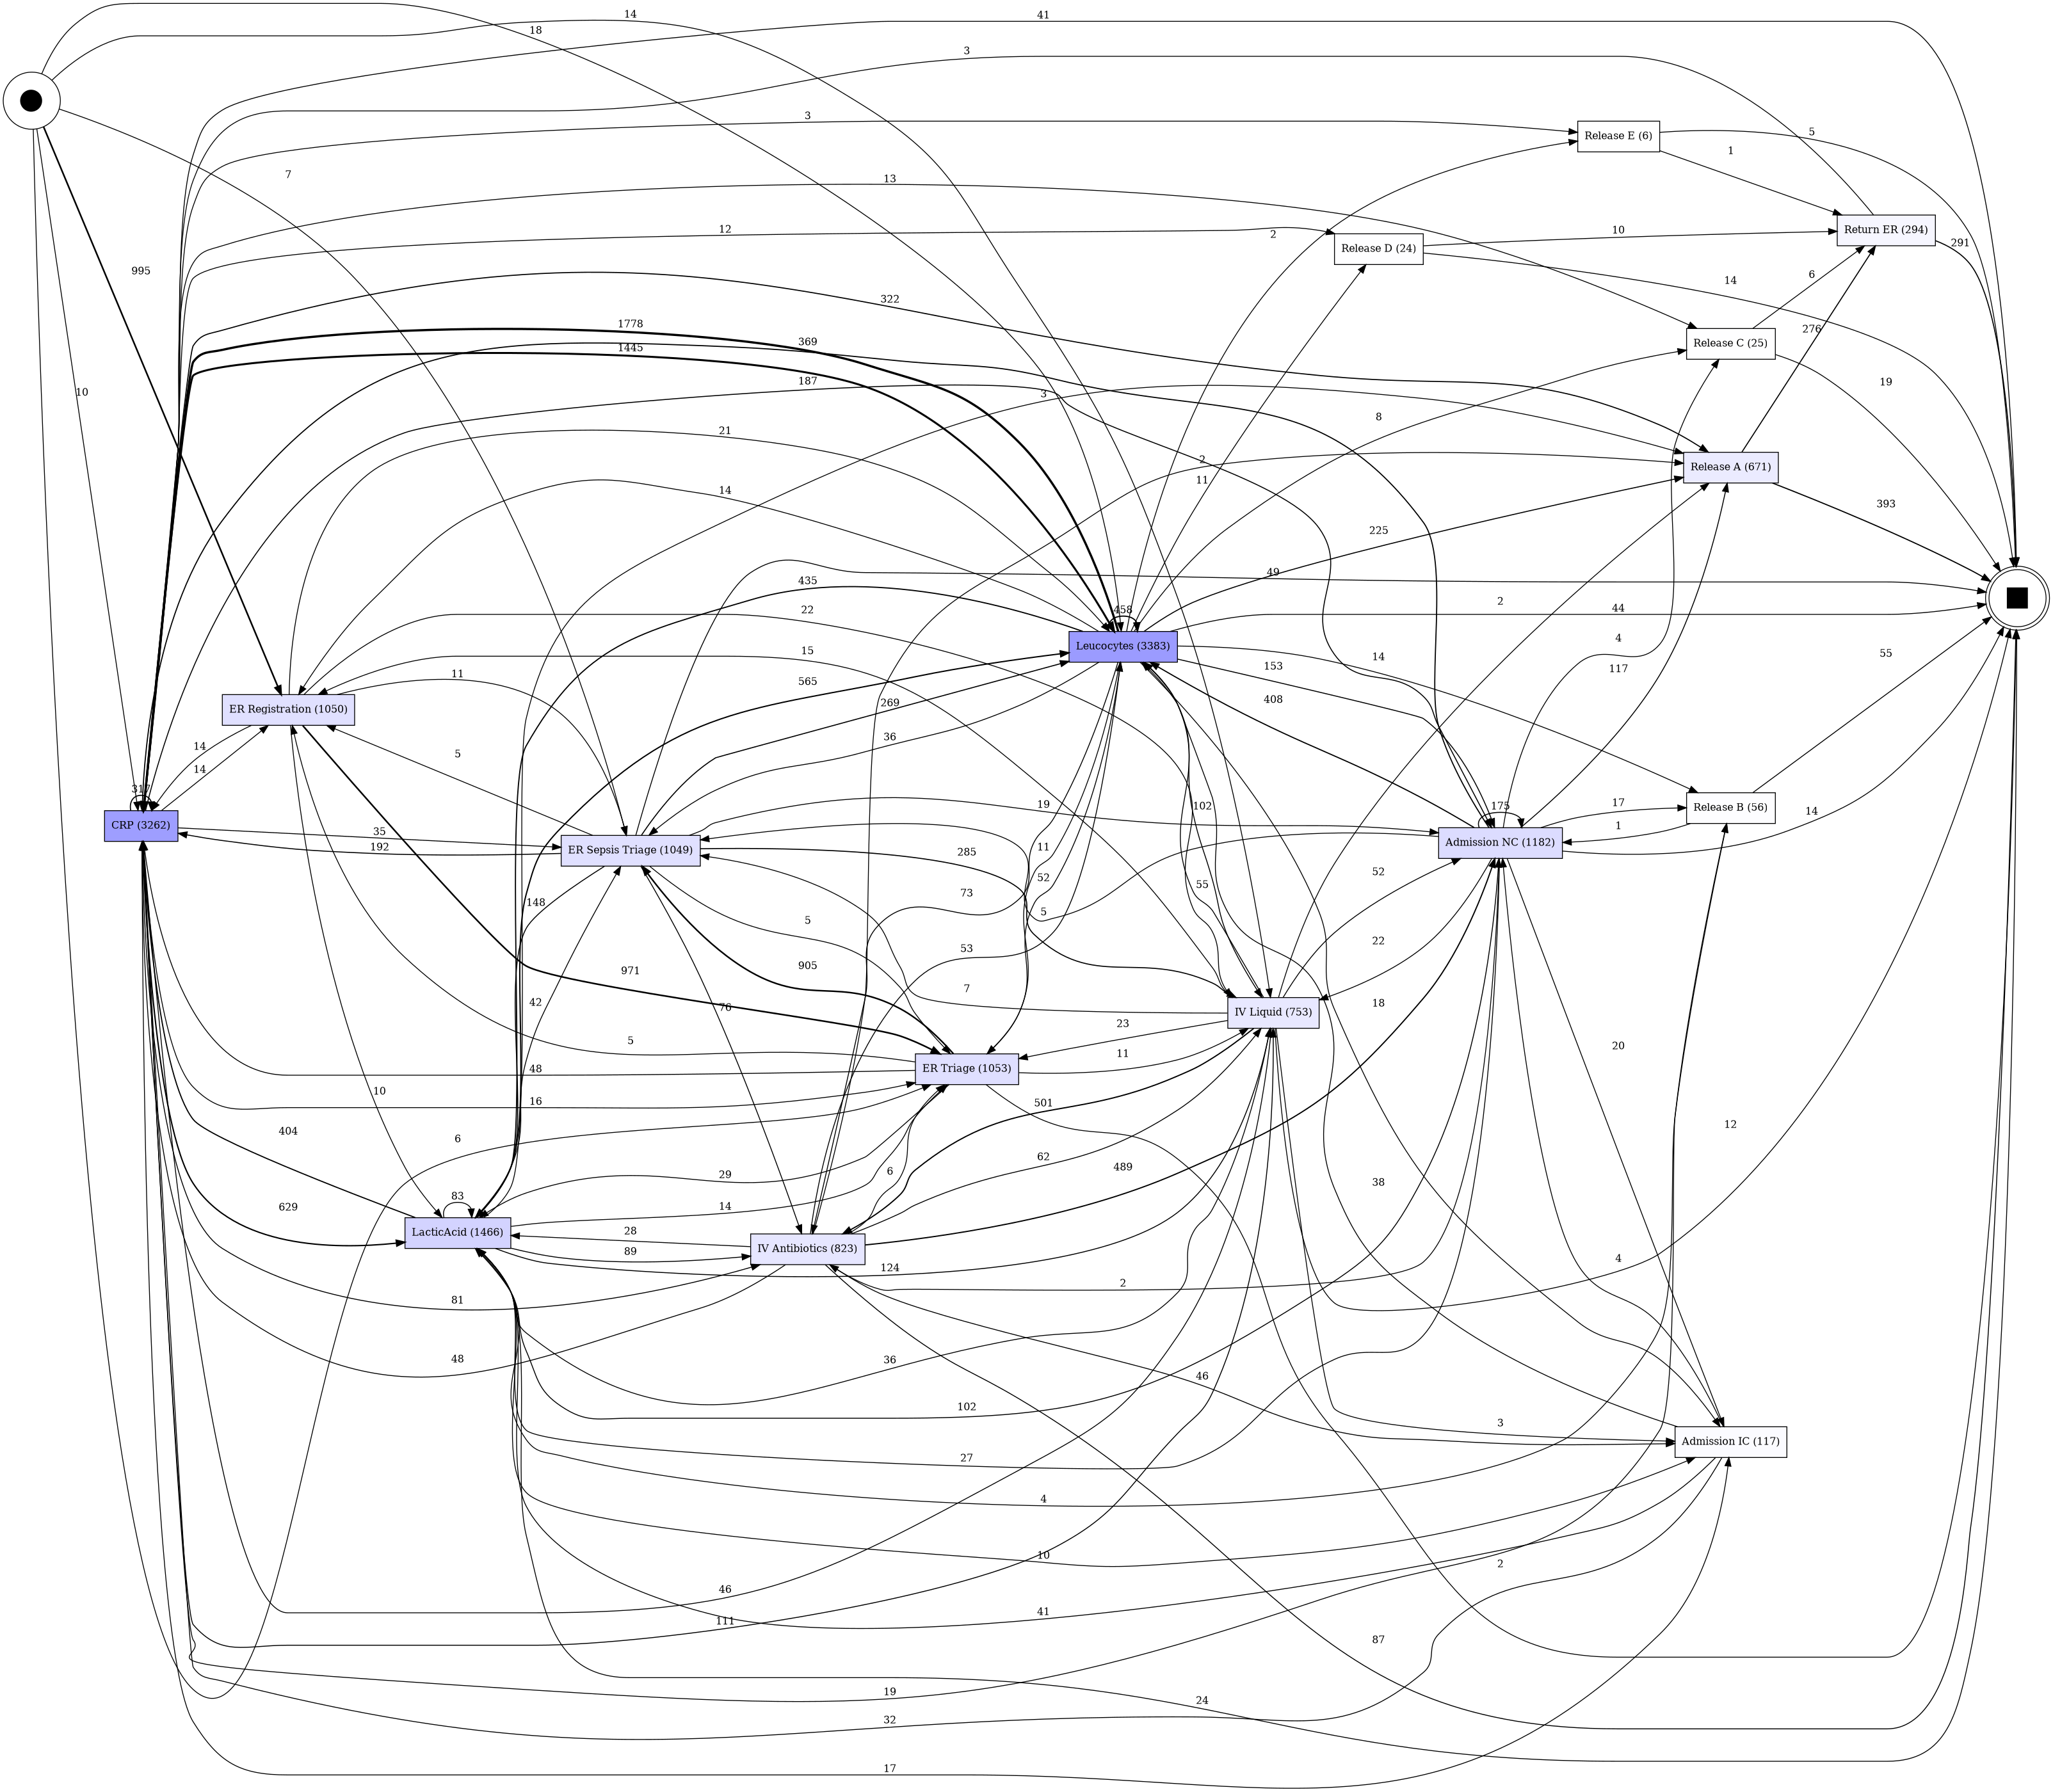

In [10]:
'''
Draw Directly follows graph
'''
dfg, start_activities, end_activities = pm4py.discover_dfg(log)
pm4py.view_dfg(dfg, start_activities, end_activities, max_num_edges=100)

Ideas
- We can dive more into the incomplete cases (what's their frequency, how do they vary etc.)
- We can dive more into the popularity of variants (how to popular with unpopular ones compare etc.)
- You can also add your own.